   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Shape of Dataset: (1338, 7)

Columns:
 Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), 

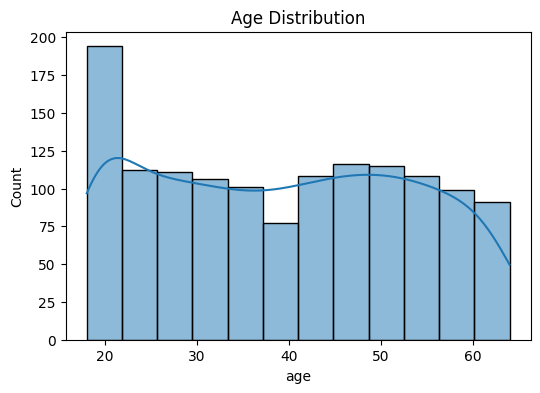

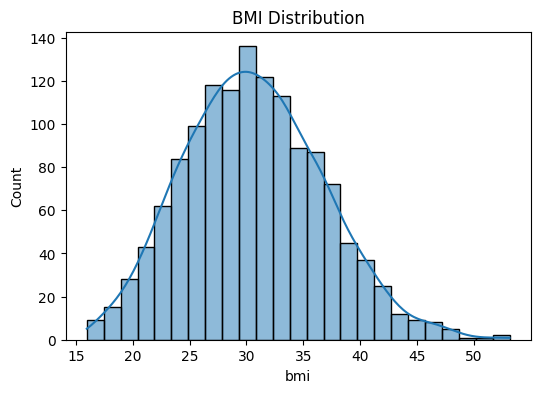

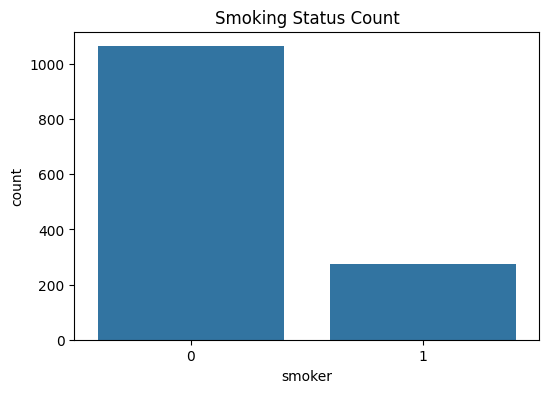

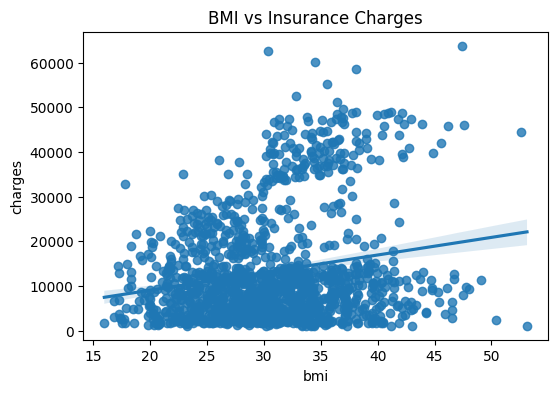

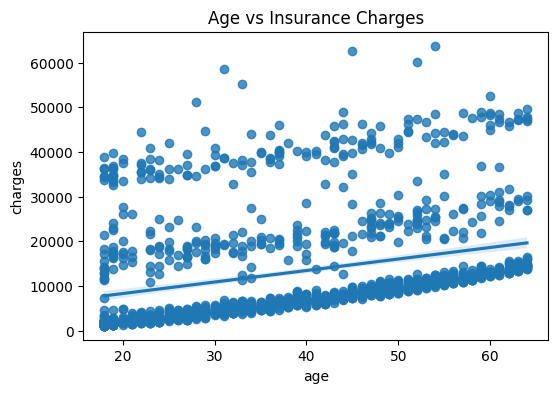

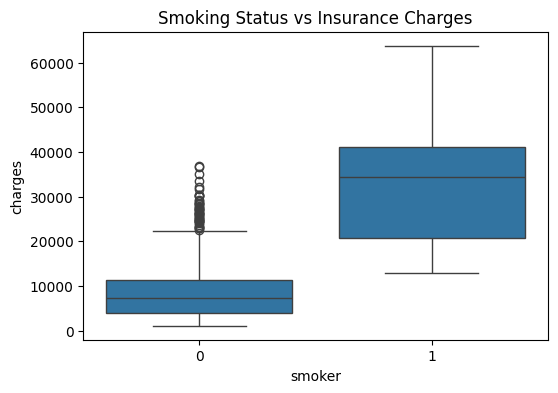


========= Linear Regression Results ========
MAE: 4181.194473753647
RMSE: 5796.284659276272


In [ ]:
# -----------------------------
## Introduction
# -----------------------------
# This project predicts medical insurance charges using Linear Regression.
# The goal is to estimate insurance costs based on personal and medical data.

# -----------------------------
## Problem Statement
# -----------------------------
# The objective is to predict insurance claim charges using features
# such as age, BMI, smoking status, and region.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------------------------------------
## Dataset Understanding and Description
# ---------------------------------------
# The dataset contains personal and medical information of individuals.


df = pd.read_csv("insurance.csv")

# Display Dataset
print(df.head())

print("\nShape of Dataset:", df.shape)

print("\nColumns:\n", df.columns)

print("\nDataset Info:")
df.info()

# -----------------------------
## Data Cleaning and Preparation
# -----------------------------
# Checking missing values and preparing data for modeling.

print("\nMissing Values:\n")
print(df.isnull().sum())

#Linear Regression only accepts numbers.
#So we must convert text into numeric format before training.

# Label Encoding
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])

df['smoker'] = le.fit_transform(df['smoker'])

# One-Hot Encoding for Region
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)


# -----------------------------
## Exploratory Data Analysis (EDA)
# -----------------------------
# Visualizing important relationships and distributions.

# -----------------------------
# Age Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True)

plt.title("Age Distribution")

plt.show()

# -----------------------------
# BMI Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], kde=True)

plt.title("BMI Distribution")

plt.show()

# -----------------------------
# Smoking Status Count
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='smoker', data=df)

plt.title("Smoking Status Count")

plt.show()

# -----------------------------
# BMI vs Charges
# -----------------------------
plt.figure(figsize=(6,4))
sns.regplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

# -----------------------------
# Age vs Charges
# -----------------------------
plt.figure(figsize=(6,4))
sns.regplot(x='age', y='charges', data=df)
plt.title("Age vs Insurance Charges")
plt.show()

# -----------------------------
# Smoker vs Charges
# -----------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoking Status vs Insurance Charges")
plt.show()

# -----------------------------
## Model Training and Testing
# -----------------------------
# Training Linear Regression model.

# Split Features and Target
X = df.drop('charges', axis=1)

y = df['charges']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
model = LinearRegression()

#Training the model
model.fit(X_train, y_train) 

#Predicting the target variable for the test set
y_pred = model.predict(X_test) 

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# -----------------------------
## Evaluation Metrics
# -----------------------------
# Evaluating model performance using MAE, RMSE, and R² Score.

print("\n========= Linear Regression Results ========")

print("MAE:", mae)

print("RMSE:", rmse)

# -----------------------------
## Conclusion
# -----------------------------
# Linear Regression was successfully used to predict medical insurance charges.
# Smoking status has a major impact on insurance charges,as smokers generally have much higher medical costs.
# Higher BMI is associated with increased insurance expenses.
# Older individuals tend to have higher insurance charges.
# Model Performance:
# - MAE: 4181.19
# - RMSE: 5796.28
# The results indicate that the Linear Regression model was able toreasonably estimate insurance charges and 
# identify important factors affecting medical costs.